# Best Country to Visit — Combined Analysis

---

This notebook combines three cleaned datasets into a single master CSV and then performs a full multivariate analysis to build a composite _'Best Country to Visit'_ index.

**Datasets used:**

| Dataset           | Source File                    | Pillar      |
| ----------------- | ------------------------------ | ----------- |
| Cost of Living    | `Cleaned_CostOfLiving.csv`     | Economy     |
| Global Weather    | `Cleaned_GlobalWeather.csv`    | Environment |
| Natural Disasters | `Cleaned_NaturalDisasters.csv` | Risk        |

## Part 1 — Data Loading & Combination

Load the three cleaned CSV files, verify each for NaN values, merge them on `country`, and export the final combined dataset.

### 1.1 — Load Datasets


In [2]:
import pandas as pd

# Load the three cleaned datasets 
cost_of_living = pd.read_csv('../Cleaned_Csvs/Cleaned_Cost_Of_Living.csv')
weather        = pd.read_csv('../Cleaned_Csvs/Cleaned_Global_Weather.csv')
disasters      = pd.read_csv('../Cleaned_Csvs/Cleaned_Natural_Disasters.csv')

print(f"Cost of Living rows : {len(cost_of_living)}")
print(f"Weather rows        : {len(weather)}")
print(f"Disasters rows      : {len(disasters)}")

for name, df in [("Cost of Living", cost_of_living), ("Weather", weather), ("Disasters", disasters)]:
    nan_counts = df.isnull().sum()
    nan_counts = nan_counts[nan_counts > 0]
    print(f"\n--- {name} NaN counts ---")
    if nan_counts.empty:
        print("  No NaN values")
    else:
        print(nan_counts.to_string())


Cost of Living rows : 203
Weather rows        : 201
Disasters rows      : 156

--- Cost of Living NaN counts ---
  No NaN values

--- Weather NaN counts ---
  No NaN values

--- Disasters NaN counts ---
  No NaN values


### 1.2 — Merge Datasets

Merge the three datasets on `country`:

- **Inner join** `CostOfLiving` + `Weather` — only countries present in both are kept.
- **Left join** filtered `Disasters` onto that 170-country set.

For disasters, missing matches after the join are treated as **structural zeros**, not random missing values. In this source, if a country has no disaster record for the scoped data, it means no recorded disaster event for that country in that period. Because of that I decided to set missing disaster indicators to `0` rather than removing them as having no disasters is a valid situation.


In [3]:
# Step 1: inner join cost_of_living + weather (both MUST be present)
combined = pd.merge(
    cost_of_living,
    weather,
    on='country',
    how='inner'
)
total_countries = len(combined)
print(f"After inner join (cost_of_living + weather): {total_countries} rows")

# Step 2: keep only disasters for countries in the 170-country combined set
countries_in_scope = combined['country'].unique()
disasters_in_scope = disasters[disasters['country'].isin(countries_in_scope)].copy()
dropped_disaster_rows = len(disasters) - len(disasters_in_scope)
print(
    f"Disaster rows kept for merge: {len(disasters_in_scope)} of {len(disasters)} "
    f"(dropped {dropped_disaster_rows} rows outside the 170-country scope)"
 )

# Numeric disaster columns from the filtered disaster dataset
disaster_numeric_cols = disasters_in_scope.select_dtypes(include='number').columns.tolist()

# Step 3: left join filtered disasters onto combined
combined = pd.merge(
    combined,
    disasters_in_scope,
    on='country',
    how='left'
)

# Keep a pre-fill copy for sensitivity checks
combined_pre_disaster_fill = combined.copy()

# Coverage out of the merged countries
countries_with_disaster_record = combined['country'].isin(disasters_in_scope['country']).sum()
countries_missing_disaster_record = total_countries - countries_with_disaster_record
print(
    f"Disaster source covers {countries_with_disaster_record} of {total_countries} merged countries "
    f"({countries_with_disaster_record / total_countries * 100:.1f}%)"
 )

# NaN checks BEFORE fill
nan_countries_before_fill = combined[disaster_numeric_cols].isna().any(axis=1).sum()
nan_cells_before_fill = combined[disaster_numeric_cols].isna().sum().sum()
total_disaster_cells = total_countries * len(disaster_numeric_cols)

print(
    f"Countries missing from disaster source (set to 0 under zero assumption): "
    f"{countries_missing_disaster_record} of {total_countries} "
    f"({countries_missing_disaster_record / total_countries * 100:.1f}%)"
 )


# Fill disaster NaNs with 0 (zero assumption for non-matching rows)
combined[disaster_numeric_cols] = combined[disaster_numeric_cols].fillna(0)

# NaN checks AFTER fill
nan_countries_after_fill = combined[disaster_numeric_cols].isna().any(axis=1).sum()
nan_cells_after_fill = combined[disaster_numeric_cols].isna().sum().sum()
print(f"After fill: countries with disaster NaN = {nan_countries_after_fill} of {total_countries}")

# Sort by country and reset index
combined = combined.sort_values('country').reset_index(drop=True)



After inner join (cost_of_living + weather): 170 rows
Disaster rows kept for merge: 125 of 156 (dropped 31 rows outside the 170-country scope)
Disaster source covers 125 of 170 merged countries (73.5%)
Countries missing from disaster source (set to 0 under zero assumption): 45 of 170 (26.5%)
After fill: countries with disaster NaN = 0 of 170


### Missing Data Method Note

In this project, disaster `NaN` values after merging are interpreted as **no matching disaster record** in the source for countries in scope. They are therefore coded as `0` , rather than guessing unknown values or trying to compute them.


### Checking Multicollinearity


1) Correlation heatmap for multicollinearity check


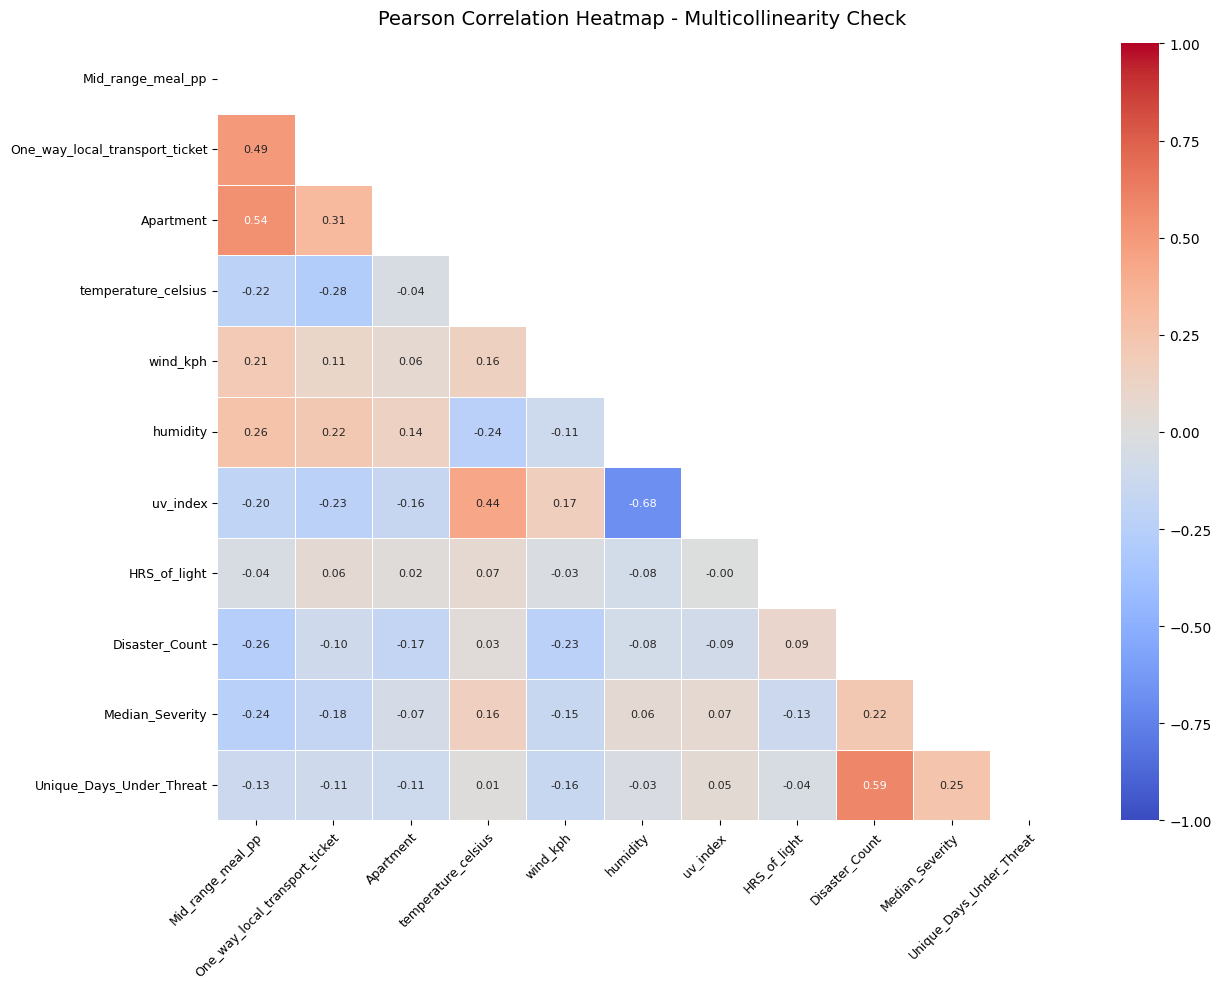


2) VIF table (VIF > 10 is typically high)
HRS_of_light                             :   27.54
humidity                                 :   18.05
temperature_celsius                      :   16.31
wind_kph                                 :    9.04
uv_index                                 :    7.00
Mid_range_meal_pp                        :    6.80
One_way_local_transport_ticket           :    3.00
Disaster_Count                           :    2.61
Apartment                                :    2.59
Median_Severity                          :    2.13
Unique_Days_Under_Threat                 :    2.00



In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor


COLS_TO_CHECK = [
    'Mid_range_meal_pp', 'One_way_local_transport_ticket', 'Apartment',
    'temperature_celsius', 'wind_kph', 'humidity', 'uv_index', 'HRS_of_light',
    'Disaster_Count', 'Median_Severity', 'Unique_Days_Under_Threat'
]

available_cols = [c for c in COLS_TO_CHECK if c in combined.columns]
missing_cols = [c for c in COLS_TO_CHECK if c not in combined.columns]

if missing_cols:
    print(f"Missing expected columns (excluded from diagnostics): {missing_cols}")

diag_df = combined[available_cols].copy()

# --- Correlation heatmap for multicollinearity check ---
print("\n1) Correlation heatmap for multicollinearity check")
corr = diag_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt=".2f",
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={"size": 8},
    ax=ax
)
ax.set_title('Pearson Correlation Heatmap - Multicollinearity Check', fontsize=14, pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor', fontsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

# --- Full VIF table ---
print("\n2) VIF table (VIF > 10 is typically high)")
vif_input = diag_df.fillna(0).values
vif_data = pd.DataFrame({
    'Variable': available_cols,
    'VIF': [variance_inflation_factor(vif_input, i) for i in range(len(available_cols))]
}).sort_values('VIF', ascending=False)

for _, row in vif_data.iterrows():
    print(f"{row['Variable']:40s} : {row['VIF']:7.2f}")

print("\n" + "=" * 70)

### 1.4 - Drop High-VIF Variables and Export Combined Dataset

After reviewing the multicollinearity heatmap and VIF table, drop `HRS_of_light` and `humidity` before running PCA, then save the updated merged dataset to `Combined_Holiday.csv`.

In [5]:
# Drop high-VIF columns before PCA analysis
# Based on the fact HRS_of_light and humidity have very high VIFs 
# and that humidity also has high correlation with UV_index 
# Ive decided to drop them to reduce multicollinearity before PCA.

drop_cols = ['HRS_of_light', 'humidity']
missing_drop_cols = [col for col in drop_cols if col not in combined.columns]
if missing_drop_cols:
    print(f"Columns not found (skipped): {missing_drop_cols}")

combined = combined.drop(columns=drop_cols, errors='ignore')
print(f"Dropped columns before PCA: {[c for c in drop_cols if c not in missing_drop_cols]}")

# Save the updated combined dataset
combined.to_csv('Combined_Holiday.csv', index=False)
print("Saved to Combined_Holiday.csv (post-drop)")
combined.info()

Dropped columns before PCA: ['HRS_of_light', 'humidity']
Saved to Combined_Holiday.csv (post-drop)
<class 'pandas.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         170 non-null    str    
 1   Mid_range_meal_pp               170 non-null    float64
 2   One_way_local_transport_ticket  170 non-null    float64
 3   Apartment                       170 non-null    float64
 4   temperature_celsius             170 non-null    float64
 5   wind_kph                        170 non-null    float64
 6   uv_index                        170 non-null    float64
 7   condition_text                  170 non-null    str    
 8   condition_category              170 non-null    str    
 9   condition_score                 170 non-null    int64  
 10  Disaster_Count                  170 non-null    float64
 11  Median_Se

# Part 2 - Multivariate Analysis: PCA for the Best Country to Visit Index

---

Principal Component Analysis (PCA) is used to uncover the underlying structure of the dataset across all **three datasets** after removing high-VIF variables (`HRS_of_light` and `humidity`):

| Dataset         | Indicators                                                       |
| --------------- | ---------------------------------------------------------------- |
| **Economy**     | `Mid_range_meal_pp`, `One_way_local_transport_ticket`, `Apartment` |
| **Environment** | `temperature_celsius`, `wind_kph`, `uv_index`                   |
| **Risk**        | `Disaster_Count`, `Median_Severity`, `Unique_Days_Under_Threat` |

PCA reduces these 9 dimensions to orthogonal components, revealing which indicators drive variance across countries and how countries cluster in reduced space.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pandas.plotting import parallel_coordinates

df = pd.read_csv('Combined_Holiday.csv')

NUMERIC_COLS = [
    'Mid_range_meal_pp', 'One_way_local_transport_ticket', 'Apartment',
    'temperature_celsius', 'wind_kph', 'uv_index',
    'Disaster_Count', 'Median_Severity', 'Unique_Days_Under_Threat'
]

## 2.1 Correlation Heatmap

Shows the pairwise correlation between all numeric features. Strong positive/negative correlations indicate variables that have high correlation.


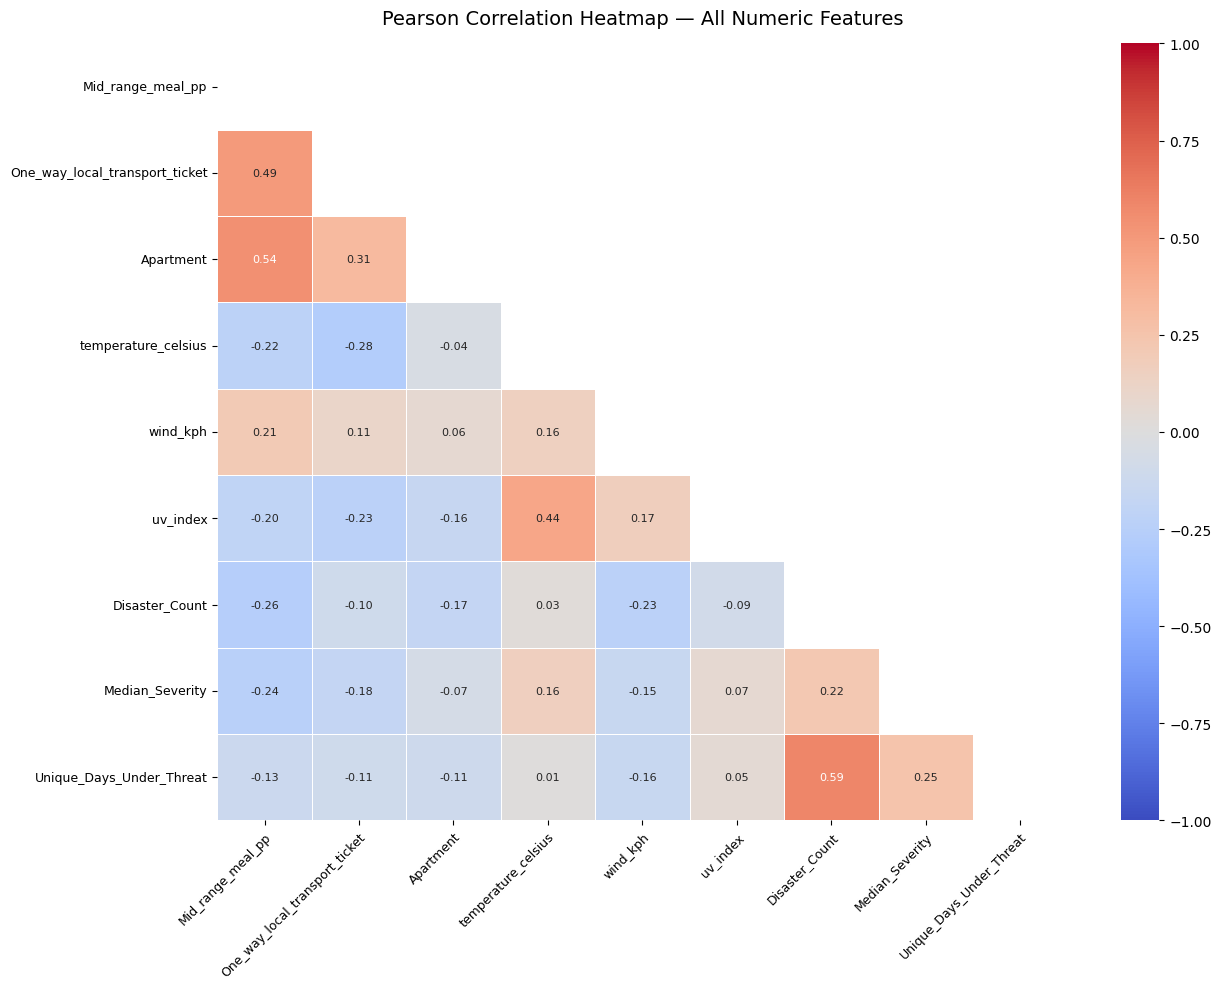

In [7]:
corr = df[NUMERIC_COLS].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle masked
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt=".2f",
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={"size": 8},
    ax=ax
)
ax.set_title('Pearson Correlation Heatmap — All Numeric Features', fontsize=14, pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor', fontsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()


### Findings

To interpret the heatmap, I used the following standard thresholds:

| Range (absolute value) | Strength                    |
| ---------------------- | --------------------------- |
| 0.8 - 1.0              | Perfect / Very Strong       |
| 0.6 - 0.8              | Strong                      |
| 0.4 - 0.6              | Moderate                    |
| 0.2 - 0.4              | Weak                        |
| 0.0 - 0.2              | Negligible / No correlation |

Using the retained variables, most relationships are expected to be weak-to-moderate, with a few stronger pairs. Re-run the heatmap and report the strongest positive and negative correlations from the updated matrix to keep this section aligned with the post-drop dataset.

In [8]:
from scipy.stats import pearsonr
pair = df[['uv_index', 'temperature_celsius']].dropna()
corr = pearsonr(pair['uv_index'], pair['temperature_celsius'])
print(corr)

pair = df[['Apartment', 'Mid_range_meal_pp']].dropna()
corr = pearsonr(pair['Apartment'], pair['Mid_range_meal_pp'])
print(corr)

PearsonRResult(statistic=np.float64(0.4352714439787705), pvalue=np.float64(2.9960984110470222e-09))
PearsonRResult(statistic=np.float64(0.5428147967366097), pvalue=np.float64(2.0614453049450806e-14))


`+0.44`: This shows a moderate positive link. As temperature rises, UV index generally rises as well, which is consistent with sunnier and warmer conditions.

`+0.54`: This shows a moderate positive link. As temperature rises, UV index generally rises as well, which is consistent with sunnier and warmer conditions.

The p-value for both is very small, well below 0.05, so the relationship is statistically significant.


## 2.3 Scree Plot

The scree plot shows how many components are needed to capture the majority of the dataset's variance. The **elbow** (where the individual bars flatten) marks the natural cut-off. The orange line shows cumulative variance.


Saved PCA-transformed data to Combined_Holiday_PCA_Scores.csv


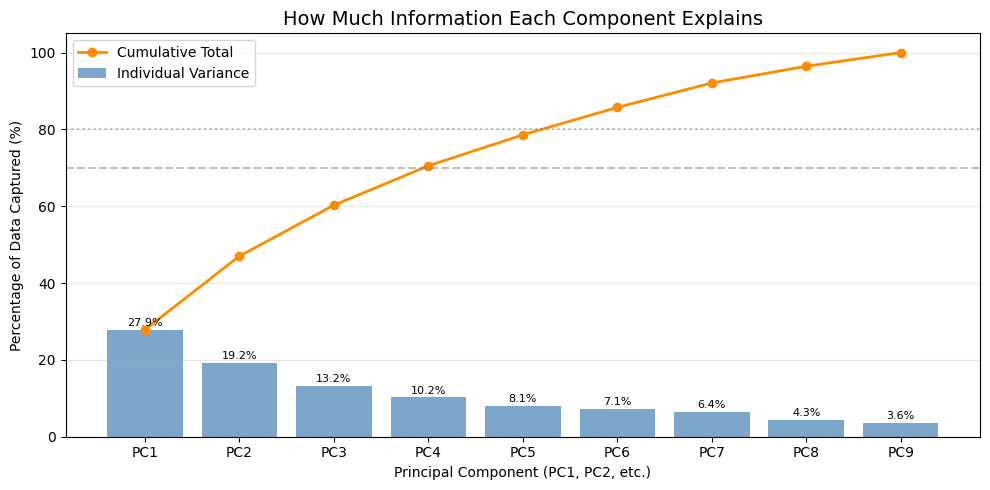

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardise 
X_std = StandardScaler().fit_transform(df[NUMERIC_COLS].fillna(0).values)

# Fit PCA on all components
pca      = PCA(random_state=42)
pca.fit(X_std)
n_comp   = len(NUMERIC_COLS)
ev_ratio = pca.explained_variance_ratio_ * 100
ev_cum   = np.cumsum(ev_ratio)

# Loadings table
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_comp)],
    index=NUMERIC_COLS
)

# Save PCA-transformed dataset (scores)
X_pca = pca.transform(X_std)
pca_scores_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_comp)])
if 'country' in df.columns:
    pca_scores_df.insert(0, 'country', df['country'].values)
pca_scores_df.to_csv('Combined_Holiday_PCA_Scores.csv', index=False)
print("Saved PCA-transformed data to Combined_Holiday_PCA_Scores.csv")

# -- Scree plot ---------------------------------------------------------------
plt.figure(figsize=(10, 5))
components = np.arange(1, n_comp + 1)

plt.bar(components, ev_ratio, color='steelblue', alpha=0.7, label='Individual Variance')
plt.plot(components, ev_cum, color='darkorange', marker='o', linewidth=2, label='Cumulative Total')

plt.axhline(y=70, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=80, color='gray', linestyle=':', alpha=0.5)

for i, percentage in enumerate(ev_ratio):
    plt.text(i + 1, percentage + 1, f'{percentage:.1f}%', ha='center', fontsize=8)

plt.title('How Much Information Each Component Explains', fontsize=14)
plt.xlabel('Principal Component (PC1, PC2, etc.)')
plt.ylabel('Percentage of Data Captured (%)')
plt.xticks(components, [f'PC{i}' for i in components])
plt.legend(loc='best')
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
pc1 = loadings['PC1'].sort_values()
print("\nPC1 Loadings (sorted strongest - weakest):")
print(loadings['PC1'].sort_values(ascending=False).round(3).to_string())

# pc2 = loadings['PC2'].sort_values()
# print("\nPC2 Loadings (sorted strongest - weakest):")
# print(loadings['PC2'].sort_values(ascending=False).round(3).to_string())

# pc3 = loadings['PC3'].sort_values()
# print("\nPC3 Loadings (sorted strongest - weakest):")
# print(loadings['PC3'].sort_values(ascending=False).round(3).to_string())

# pc4 = loadings['PC4'].sort_values()
# print("\nPC4 Loadings (sorted strongest - weakest):")
# print(loadings['PC4'].sort_values(ascending=False).round(3).to_string())

# pc5 = loadings['PC5'].sort_values()
# print("\nPC5 Loadings (sorted strongest - weakest):")
# print(loadings['PC5'].sort_values(ascending=False).round(3).to_string())

# pc6 = loadings['PC6'].sort_values()
# print("\nPC6 Loadings (sorted strongest - weakest):")
# print(loadings['PC6'].sort_values(ascending=False).round(3).to_string())



PC1 Loadings (sorted strongest - weakest):
Mid_range_meal_pp                 0.494
One_way_local_transport_ticket    0.413
Apartment                         0.378
wind_kph                          0.177
uv_index                         -0.221
temperature_celsius              -0.244
Median_Severity                  -0.301
Unique_Days_Under_Threat         -0.310
Disaster_Count                   -0.341


### Scree Plot Interpretation

To develop a meaningful composite indicator, I performed **Principal Component Analysis (PCA)** on the 9 retained numeric variables in the dataset. This allowed me to study the underlying structure of the data and ensure that the final index represents a truly multidimensional concept, rather than being driven by a single factor.

The scree plot shows a clear leveling pattern after PC6, so I retain **only the first 6 principal components** for index construction.

- **Why 6 PCs:** PC1-PC6 capture the dominant structure of the dataset before marginal gains flatten out.
- **Variance Captured:** The first 6 PCs explain roughly **86%** of total variance, which is strong coverage for a composite index.
- **Solves Double Counting:** The dataset contains multiple indicators for related concepts (for example, costs). PCA groups shared variance into common components, so one pillar does not dominate simply because it has more columns.
- **Handles Multicollinearity:** Correlated inputs are transformed into **orthogonal (uncorrelated) components**, reducing redundancy and giving a cleaner basis for combining Economy, Environment, and Risk dimensions into one index.
- **Dimensionality:** Retaining 6 PCs keeps the final _'Best Country to Visit'_ index multidimensional, rather than collapsing into a single-factor score.

## 2.4 - Check Variables for Problems

Before building the final index, I check if any of my 9 retained variables have problems that would distort scoring. I look for:

1. **Does one variable dominate the others?** (VIF score)
2. **Do I have missing data?**
3. **Does the variable actually change, or is it always the same?**

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

print("\n" + "=" * 70)
print("VARIABLE QUALITY CHECKS")
print("=" * 70)

# --- Check for Multicollinearity (VIF) ---
print("\n1. MULTICOLLINEARITY (VIF > 10 = problem)")
print("-" * 70)

vif_data = pd.DataFrame()
vif_data["Variable"] = NUMERIC_COLS
vif_data["VIF"] = [variance_inflation_factor(df[NUMERIC_COLS].fillna(0).values, i)
                   for i in range(len(NUMERIC_COLS))]
vif_data = vif_data.sort_values("VIF", ascending=False)

for idx, row in vif_data.iterrows():
    var_name = row["Variable"]
    vif_val = row["VIF"]
    print(f"{var_name:40s} : {vif_val:7.2f}")

print("")
print("NOTE: I do not want to drop temperature_celsius as its just a little over 10 on the VIF")
print("scale and doesn't appear to be heavily correlated with other variables. In my opinion")
print("its also an essential variable to keep for the analysis a ")

# --- Check for Missing Data ---
print("\n2. MISSING DATA")
print("-" * 70)
missing_pct = (df[NUMERIC_COLS].isnull().sum() / len(df) * 100)
print(f"{(missing_pct == 0).sum()}/{len(NUMERIC_COLS)} variables have zero missing data")

# --- Check for Variance ---
print("\n3. VARIANCE (Standard Deviation)")
print("-" * 70)
for col in NUMERIC_COLS:
    std_dev = df[col].std()
    print(f"{col:40s} : {std_dev:8.2f}")

# --- Simple clustering diagnostic 
print("\n4. CLUSTER CHECK (k and silhouette)")
print("-" * 70)
print("silhouette ranges from -1 to 1:")
print("  close to 1  -> clusters are clearly separated")
print("  around 0    -> overlap / weak separation")
print("  below 0     -> poor grouping")

X_check = StandardScaler().fit_transform(df[NUMERIC_COLS].fillna(0).values)
X_check = PCA(n_components=6, random_state=42).fit_transform(X_check)

sil_scores = []
for k in range(2, 9):
    labels = KMeans(n_clusters=k, random_state=42, n_init=25).fit_predict(X_check)
    sil = silhouette_score(X_check, labels)
    sil_scores.append(sil)
    print(f"k={k}: silhouette={sil:.3f}")

print(f"\nSilhouettes range from: {min(sil_scores):.3f} to {max(sil_scores):.3f}")
print("Conclusion: clustering exists but is weak-to-moderate, not cleanly separated. " \
"Therefore, I will not use.")

print("\n" + "=" * 70)


VARIABLE QUALITY CHECKS

1. MULTICOLLINEARITY (VIF > 10 = problem)
----------------------------------------------------------------------
temperature_celsius                      :   10.71
wind_kph                                 :    8.20
Mid_range_meal_pp                        :    5.96
uv_index                                 :    4.65
One_way_local_transport_ticket           :    2.83
Apartment                                :    2.55
Disaster_Count                           :    2.34
Unique_Days_Under_Threat                 :    1.96
Median_Severity                          :    1.94

NOTE: I do not want to drop temperature_celsius as its just a little over 10 on the VIF
scale and doesn't appear to be heavily correlated with other variables. In my opinion
its also an essential variable to keep for the analysis a 

2. MISSING DATA
----------------------------------------------------------------------
9/9 variables have zero missing data

3. VARIANCE (Standard Deviation)
---------

## 2.6 — Why I will not be using Clustering

The goal of my project is to build a **Best Country to Visit ranking index (0.00–1.00)** for travel decisions, not to force countries into a small number of hard groups. From an index-design perspective, clustering is optional and can reduce interpretability for my objective.

1. **Research objective mismatch**
   Clustering answers: "Which countries are similar enough to group together?"_
   My goal is to answers: "How good is each country based on a travel score?"_
   PCA is directly aligned with ranking while clustering is primarily a segmentation tool.

2. **Weak natural separation in the data**
   Using the same 6-PC representation retained for the index (86% variance), KMeans silhouette values are only around **0.23–0.28** across various k values from 2–8. In practice, this indicates weak-to-moderate cluster structure rather than strong, cleanly separated country blocs.

3. **Information loss from hard labels**
   Cluster labels collapse continuous variation into a few categories. Two countries with meaningfully different costs or risk profiles can end up in the same bucket, which is less useful than a ranked index when making destination comparisons.


# Part 3 - Composite Index: Best Country to Visit Score

---

With the PCA structure understood and clustering ruled out, I now build a single **0.00 - 1.00 composite score** for each country. The approach is:

1. **Min-Max normalise** every indicator so all variables are on the same 0-1 scale.
2. **Invert** indicators where _lower = better_ (costs, wind, disasters, severity, days under threat).
3. **Weight** the pillars and sum to produce the final index.


**NOTE** - In cleaning weather i grouped conditions into 6 groups and ordered them 0-5 , 0 being the worst condition related to a holiday(thunderstorms) and 5 being the best (clear) so having a higher condition value means better conditions.

## 3.1 Pillar Design & Weights

Each of the three cleaned datasets maps to one **pillar** in the final index.

| Pillar          | Weight | Indicators                                                                 | Direction                            |
| --------------- | ------ | -------------------------------------------------------------------------- | ------------------------------------ |
| **Economy**     | 35 %   | `Mid_range_meal_pp`, `One_way_local_transport_ticket`, `Apartment`         | lower cost = higher score (inverted) |
| **Environment** | 40 %   | `temperature_celsius`, `wind_kph`, `uv_index`, `condition_category`        | mixed (see each seperate index file) |
| **Risk**        | 25 %   | `Disaster_Count`, `Median_Severity`, `Unique_Days_Under_Threat`            | lower risk = higher score (inverted) |

### Weight Rationale

#### Environment - 40%

The Environment pillar is assigned the highest weight because weather comfort, seasonal stability, and climate conditions are the primary **"pull factors"** that create travel desire in the first place.

This is benchmarked against the **George Washington University Adventure Tourism Development Index (ATDI)**, which allocates exactly 40% of its total index weight to its _Resources_ dimension - incorporating natural beauty, climate resilience, and operational windows. The ATDI explicitly highlights that strong environmental assets carry the greatest weight because they have the unique power to **offset a country's infrastructural or economic shortcomings**.

Source: [GWU Adventure Tourism Development Index](https://iits.business.gwu.edu/adventure-tourism-development-index)

---

#### Economy - 35%

The Economy pillar is weighted second because localised cost of living and consumer pricing act as the **immediate secondary threshold for trip feasibility**.

This aligns with the **World Economic Forum (WEF) Travel & Tourism Development Index 2024**, which isolates consumer costs under _Pillar 8: Price Competitiveness_ - measuring Purchasing Power Parity (PPP) and lodging indicators - categorising them as critical _Enabling Conditions_. WEF data shows that macro-environmental appeal is effectively bottlenecked if local costs spike, as travellers aggressively substitute expensive nations for more budget-favourable regional alternatives.

Source: [WEF Travel & Tourism Development Index 2024](https://www3.weforum.org/docs/WEF_Travel_and_Tourism_Development_Index_2024.pdf)

---

#### Risk - 25%

While safety is non-negotiable, the Risk pillar is weighted lowest because it functions as a **baseline constraint** rather than an active travel motivator.

This is grounded in the empirical findings of a study published in _Progress in Tourism Management_ **(Karl, 2020)**, which mapped how travellers mentally process different types of danger. The study reveals that while acute threats like health crises, terrorism, and political instability dominate traveller risk perception, **natural hazards and disasters reside in a significantly lower bracket** during early-stage planning. Risk behaves as a late-stage filter used to rule out untenable destinations, rather than the reason someone chooses to visit. Keeping this at 25% ensures the index maintains a strict safety baseline without letting it overshadow core holiday appeal.

Source: [Karl (2020) - PMC7494559](https://pmc.ncbi.nlm.nih.gov/articles/PMC7494559/)

---

## 3.2 — 3.4 Implementation

The normalisation, scoring, and ranking code are in individual index notebooks:

- **`index_cheapest_warmest_country.ipynb`** — scores countries favouring high temperature
- **`index_cheapest_coldest_country.ipynb`** — scores countries favouring low temperature 
